
Searching Same Key in Both Algorithms...


PERFORMANCE COMPARISON TABLE

 Array Size  Binary Time (µs)  Binary Comparisons Binary Time Complexity Binary Space Complexity  Interpolation Time (µs)  Interpolation Comparisons Interpolation Time Complexity Interpolation Space Complexity
       1000         13.599871                  10               O(log n)                    O(1)                 8.800067                          1              O(log log n) Avg                           O(1)
       5000          7.400056                  13               O(log n)                    O(1)                 5.300157                          1              O(log log n) Avg                           O(1)
      10000          4.600035                  10               O(log n)                    O(1)                 2.600020                          1              O(log log n) Avg                           O(1)
      50000         11.999859                  15               O(log n)              

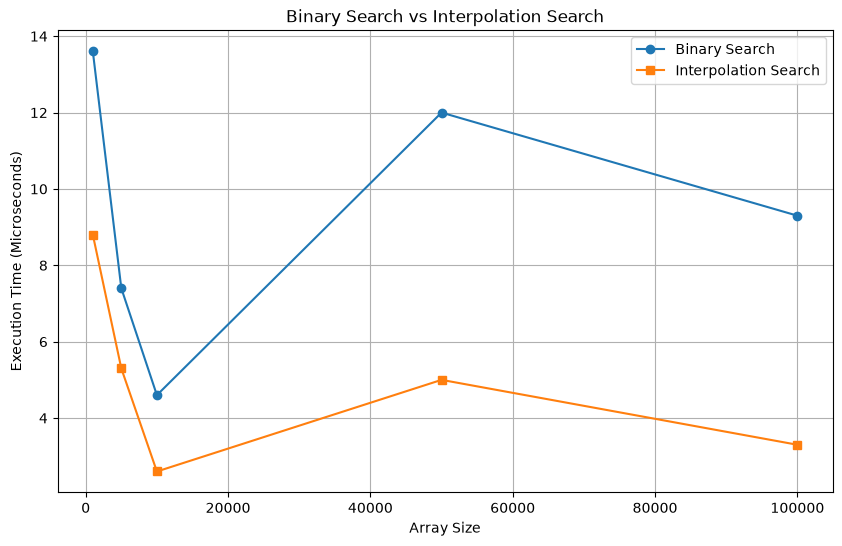

In [1]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

# Binary Search
def binary_search(arr, key):
    left = 0
    right = len(arr) - 1
    comparisons = 0

    while left <= right:
        comparisons += 1
        mid = (left + right) // 2

        if arr[mid] == key:
            return mid, comparisons

        elif arr[mid] < key:
            left = mid + 1

        else:
            right = mid - 1

    return -1, comparisons


# Interpolation Search
def interpolation_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high and key >= arr[low] and key <= arr[high]:

        comparisons += 1

        if low == high:
            if arr[low] == key:
                return low, comparisons
            return -1, comparisons

        pos = low + int(
            ((high - low) / (arr[high] - arr[low]))
            * (key - arr[low])
        )

        if arr[pos] == key:
            return pos, comparisons

        if arr[pos] < key:
            low = pos + 1

        else:
            high = pos - 1

    return -1, comparisons


# Array sizes
sizes = [1000, 5000, 10000, 50000, 100000]

results = []

binary_times = []
interpolation_times = []

print("\nSearching Same Key in Both Algorithms...\n")

for size in sizes:

    # Generate sorted array
    arr = list(range(size))

    # Select same key
    key = random.choice(arr)

    # Binary Search
    start = time.perf_counter()
    index_b, comp_b = binary_search(arr, key)
    end = time.perf_counter()

    binary_time = (end - start) * 1000000  # microseconds

    # Interpolation Search
    start = time.perf_counter()
    index_i, comp_i = interpolation_search(arr, key)
    end = time.perf_counter()

    interpolation_time = (end - start) * 1000000  # microseconds

    binary_times.append(binary_time)
    interpolation_times.append(interpolation_time)

    results.append([
        size,
        binary_time,
        comp_b,
        "O(log n)",
        "O(1)",
        interpolation_time,
        comp_i,
        "O(log log n) Avg",
        "O(1)"
    ])


# Create DataFrame
columns = [
    "Array Size",
    "Binary Time (µs)",
    "Binary Comparisons",
    "Binary Time Complexity",
    "Binary Space Complexity",
    "Interpolation Time (µs)",
    "Interpolation Comparisons",
    "Interpolation Time Complexity",
    "Interpolation Space Complexity"
]

df = pd.DataFrame(results, columns=columns)

print("\nPERFORMANCE COMPARISON TABLE\n")
print(df.to_string(index=False))


# Plot Graph
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    binary_times,
    marker='o',
    label='Binary Search'
)

plt.plot(
    sizes,
    interpolation_times,
    marker='s',
    label='Interpolation Search'
)

plt.title("Binary Search vs Interpolation Search")
plt.xlabel("Array Size")
plt.ylabel("Execution Time (Microseconds)")
plt.grid(True)
plt.legend()

plt.show()